# Nexus cycle attribution (v2)

Logic lives in `src/v2/scripts/` — this notebook is the driver.

Constants: `scripts/config.toml`.


In [1]:
import sys
from datetime import date
from pathlib import Path

import pandas as pd

# make scripts importable when the kernel cwd is anywhere under the repo
SCRIPTS = Path('/home/ajain/apeksha/pnl_attribution/src/v2/scripts')
ROOT = SCRIPTS.parent  # src/v2
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from scripts import CONFIG, get_ch_client
from scripts.day_attribution import attribute_all_books_day, attribute_book_day

client = get_ch_client()
print('books =', len(CONFIG.book_names))
print('contract size =', CONFIG.contract.size, '| clearing =', CONFIG.contract.clearing_rate)


books = 10
contract size = 1000 | clearing = 0.0019


### `position_received` vs `nexus_transfers`

Day / cycle check that intention `position_received` equals pack-expanded transfers:
- spread space (front month), not outrights
- multi-month packs → same lots on each consecutive 1m front
- book sign: desk buy → −, desk sell → +
- `source_book` filter; London hour ≥ 21 (EOD roll) excluded

Near-simultaneous cycles are coalesced (1s) for the per-cycle window check.

In [2]:
import sys
from datetime import date
from pathlib import Path

ROOT = Path('/home/ajain/apeksha/pnl_attribution/src/v2')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from scripts import get_ch_client
from scripts.diagnostics import (
    check_position_received_vs_transfers,
    check_position_received_vs_transfers_range,
)

client = get_ch_client()
BOOK = 'Hedger Spreads'
START, END = date(2026, 9, 17), date(2026, 9, 30)

day_summary = check_position_received_vs_transfers_range(client, BOOK, START, END)
print(day_summary.to_string(index=False))
print()
print('exact days', int(day_summary['ok'].sum()), '/', len(day_summary))
if (~day_summary['ok']).any():
    print('mismatches:')
    print(day_summary.loc[~day_summary['ok']].to_string(index=False))

# detail one day (cycles + tenor deltas)
sample = date(2026, 9, 17)
out = check_position_received_vs_transfers(client, sample, BOOK)
print(f'\n=== {sample} {BOOK} ===')
display(out['day'])
cyc = out['cycles']
print(f"cycle groups ok {int(cyc['ok'].sum())}/{len(cyc)}")
if (~cyc['ok']).any():
    display(cyc.loc[~cyc['ok']])
tenor_delta = out['tenor'].loc[out['tenor']['delta'].abs() > 1e-9]
if not tenor_delta.empty:
    print('tenor residuals:')
    display(tenor_delta)

      date           book  n_cycles  n_transfers  abs_received  abs_transfers  signed_received  signed_transfers  abs_diff    ok
2026-09-17 Hedger Spreads       476          956        6035.0         6035.0          -6019.0           -6019.0       0.0  True
2026-09-18 Hedger Spreads       446          854        1773.0         1773.0           1261.0            1261.0       0.0  True
2026-09-21 Hedger Spreads       462          916        3307.0         3307.0          -1565.0           -1565.0       0.0  True
2026-09-22 Hedger Spreads       428          907        2364.0         2364.0          -1512.0           -1512.0       0.0  True
2026-09-23 Hedger Spreads       361          765        2332.0         2332.0           1970.0            1970.0       0.0  True
2026-09-24 Hedger Spreads       351          609        4793.0         4791.0            457.0             459.0       2.0 False
2026-09-25 Hedger Spreads       243          525        2169.0         2169.0          -1233.0   

,date,book,n_cycles,n_transfers,abs_received,abs_transfers,signed_received,signed_transfers,abs_diff,ok
0,2026-09-17,Hedger Spreads,476,956,6035.0,6035.0,-6019.0,-6019.0,0.0,True


cycle groups ok 473/473


### Market risk + deal vs mark / all days

Day-total **$** (+ = gain, library m2m sign):
- `transfer_vs_mark` — transfer deal vs **Nexus transfer `mark`** (`≈ −edge`; small). First column.
- `transfer_pred` / `pca` / `routing` — held MR over the cycle window
- `unexecuted` / `executed_mr` — residual / fill timing MR
- `mark_to_exec` — hedge fill vs algo curve at fill (`price/n`)

Table includes a **`total`** column (sum of components). With multiple days, a **`TOTAL`** row sums across dates.

In [4]:
BOOK = 'Hedger Spreads'
START = date(2026, 9, 17)
END = date.today()

dates = pd.date_range(START, END, freq='D').date.tolist()
rows = []
for d in dates:
    print(f'=== {d} {BOOK} market risk ===')
    one = attribute_book_day(client, d, BOOK, progress_every=0)
    if one.empty or 'DAY TOTAL' not in one.index:
        print('  (no cycles)')
        continue
    day = one.loc['DAY TOTAL']
    rows.append({
        'date': d,
        'transfer_vs_mark': float(day[('$', 'transfer_pred', 'transfer_vs_mark')]),
        'transfer_pred_mr': float(day[('$', 'transfer_pred', 'held_market_risk')]),
        'pca_mr': float(day[('$', 'pca', 'held_market_risk')]),
        'routing_mr': float(day[('$', 'routing', 'held_market_risk')]),
        'unexecuted_mr': float(day[('$', 'executed', 'held_market_risk')]),
        'executed_mr': float(day[('$', 'executed', 'executed_market_risk')]),
        'mark_to_exec': float(day[('$', 'executed', 'mark_to_exec')]),
    })

COMPONENT_COLS = [
    'transfer_vs_mark',
    'transfer_pred_mr',
    'pca_mr',
    'routing_mr',
    'unexecuted_mr',
    'executed_mr',
    'mark_to_exec',
]

mr_all_days = pd.DataFrame(rows).set_index('date')
mr_all_days['total'] = mr_all_days[COMPONENT_COLS].sum(axis=1)
if len(mr_all_days) > 1:
    mr_all_days.loc['TOTAL'] = mr_all_days.sum(numeric_only=True)

display_cols = COMPONENT_COLS + ['total']
mr_all_days = mr_all_days.reindex(columns=display_cols)
mr_all_days.round(2)

=== 2026-09-17 Hedger Spreads market risk ===
  Hedger Spreads: prefetching market data (476 cycles)…
=== 2026-09-18 Hedger Spreads market risk ===
  Hedger Spreads: prefetching market data (446 cycles)…
=== 2026-09-19 Hedger Spreads market risk ===
  (no cycles)
=== 2026-09-20 Hedger Spreads market risk ===
  (no cycles)
=== 2026-09-21 Hedger Spreads market risk ===
  Hedger Spreads: prefetching market data (462 cycles)…
=== 2026-09-22 Hedger Spreads market risk ===
  Hedger Spreads: prefetching market data (428 cycles)…
=== 2026-09-23 Hedger Spreads market risk ===
  Hedger Spreads: prefetching market data (361 cycles)…
=== 2026-09-24 Hedger Spreads market risk ===
  Hedger Spreads: prefetching market data (351 cycles)…
=== 2026-09-25 Hedger Spreads market risk ===
  Hedger Spreads: prefetching market data (243 cycles)…
=== 2026-09-26 Hedger Spreads market risk ===
  (no cycles)
=== 2026-09-27 Hedger Spreads market risk ===
  (no cycles)
=== 2026-09-28 Hedger Spreads market risk ===


,transfer_vs_mark,transfer_pred_mr,pca_mr,routing_mr,unexecuted_mr,executed_mr,mark_to_exec,total
date,,,,,,,,
2026-09-17,-2336.78,0.0,15199.54,-177.67,-71466.93,-81971.17,11544.25,-129208.76
2026-09-18,84.82,0.0,11921.27,899.11,-18977.49,-13709.73,-1433.47,-21215.49
2026-09-21,8903.40,0.0,12332.50,-62.48,-12391.40,-18831.54,-7933.08,-17982.60
2026-09-22,-651.20,0.0,10823.89,87.23,-10120.94,-39388.18,5267.52,-33981.68
2026-09-23,211.64,0.0,19065.38,407.26,-9449.27,-24763.32,2623.59,-11904.72
2026-09-24,13916.58,0.0,-1512.05,29597.79,-30085.91,-6821.94,-5247.22,-152.75
2026-09-25,5594.65,0.0,5055.04,-4808.58,-5447.90,-26696.19,-4691.57,-30994.55
2026-09-28,3186.32,0.0,3157.16,-96.04,-24018.34,-20546.27,-759.06,-39076.23
2026-09-29,-3525.30,0.0,16860.93,18.56,-4464.06,-31976.72,-1443.30,-24529.89


### Per-cycle breakdown (one date)

Same components as the day table, one row per `cycle_id`. Set `CYCLE_DATE` below.

In [9]:
CYCLE_DATE = date(2026, 9, 24)
BOOK = 'Hedger Spreads'

COMPONENT_COLS = [
    'transfer_vs_mark',
    'transfer_pred_mr',
    'pca_mr',
    'routing_mr',
    'unexecuted_mr',
    'executed_mr',
    'mark_to_exec',
]

print(f'=== {CYCLE_DATE} {BOOK} per cycle ===')
one = attribute_book_day(client, CYCLE_DATE, BOOK, progress_every=0)
if one.empty or 'DAY TOTAL' not in one.index:
    mr_by_cycle = pd.DataFrame(columns=COMPONENT_COLS + ['total'])
    print('(no cycles)')
else:
    cycles_only = one.drop(index='DAY TOTAL', errors='ignore')
    rows = []
    for cid, row in cycles_only.iterrows():
        rows.append({
            'cycle_id': cid,
            'transfer_vs_mark': float(row[('$', 'transfer_pred', 'transfer_vs_mark')]),
            'transfer_pred_mr': float(row[('$', 'transfer_pred', 'held_market_risk')]),
            'pca_mr': float(row[('$', 'pca', 'held_market_risk')]),
            'routing_mr': float(row[('$', 'routing', 'held_market_risk')]),
            'unexecuted_mr': float(row[('$', 'executed', 'held_market_risk')]),
            'executed_mr': float(row[('$', 'executed', 'executed_market_risk')]),
            'mark_to_exec': float(row[('$', 'executed', 'mark_to_exec')]),
        })
    mr_by_cycle = pd.DataFrame(rows).set_index('cycle_id')
    mr_by_cycle['total'] = mr_by_cycle[COMPONENT_COLS].sum(axis=1)
    mr_by_cycle.loc['DAY TOTAL'] = mr_by_cycle.sum(numeric_only=True)
    mr_by_cycle = mr_by_cycle.reindex(columns=COMPONENT_COLS + ['total'])

mr_by_cycle.round(2)

=== 2026-09-24 Hedger Spreads per cycle ===
  Hedger Spreads: prefetching market data (351 cycles)…


,transfer_vs_mark,transfer_pred_mr,pca_mr,routing_mr,unexecuted_mr,executed_mr,mark_to_exec,total
cycle_id,,,,,,,,
5a0103b8-f4d8-4f01-8327-8bf87febe105,164.86,0.0,104.37,1.93,-2155.95,-16.88,-10.03,-1911.70
ecabf139-d1ff-4d32-bdfd-3535dbbf409b,2.54,0.0,-179.97,-4.41,-8.64,54.14,-13.62,-149.96
729062cf-7248-45eb-8080-057ac60e7576,3.51,0.0,645.00,-4.97,33.86,63.01,410.80,1151.21
ea44775a-a7a1-4184-9a23-be6b1a640093,1.11,0.0,230.08,0.05,-0.75,0.00,0.00,230.49
bc8455be-6b56-4cd5-9a9a-a841fe04a269,-0.07,0.0,242.03,0.07,-213.21,21.53,-197.93,-147.58
...,...,...,...,...,...,...,...,...
b7529a52-ab82-4420-a993-86ca621c76d7,0.00,0.0,3630.03,3710.41,-1811.69,-24.92,-16.74,5487.09
6485133e-cde9-4768-ab4b-c7a7d6682da4,-0.01,0.0,-1009.30,-671.01,-7163.10,-268.23,89.45,-9022.20
b9b15661-f0b6-42da-b254-0c923d2b33c2,-0.00,0.0,376.06,204.00,3454.01,0.00,0.00,4034.07


### `executed_mr` by contract (`instrument_key`)

Same timing MR as the day total, split by raw `nexus_trades.instrument_key` (packs stay as multi-month calendars). Sorted by `|executed_mr|`.

`abs_lots` = Σ |trade quantity| (contract lots, not 1m-expanded).  
`c/bbl` = `−executed_mr / (abs_lots × 1000) × 100` (+ = cost, − = gain).

In [3]:
from scripts.day_attribution import executed_mr_by_instrument_book_day

EXEC_MR_DATE = date(2026, 9, 17)
BOOK = 'Hedger Spreads'

exec_mr_by_contract = executed_mr_by_instrument_book_day(
    client, EXEC_MR_DATE, BOOK
)
print(f'=== {EXEC_MR_DATE} {BOOK} executed_mr by instrument_key ===')
if exec_mr_by_contract.empty:
    print('(no fills)')
else:
    print(
        f"day Σ executed_mr {float(exec_mr_by_contract['executed_mr'].sum()):,.2f}  "
        f"|lots| {float(exec_mr_by_contract['abs_lots'].sum()):,.0f}"
    )
exec_mr_by_contract.sort_values(by='c/bbl', ascending=False)

=== 2026-09-17 Hedger Spreads executed_mr by instrument_key ===
day total -81,971.08


,executed_mr,n_fills,abs_lots,c/bbl
instrument_key,,,,
ICE BRN Dec26-Jun27 Calendar,-14069.94,246,256.0,5.4961
ICE BRN Dec26-Dec27 Calendar,-21731.48,229,453.0,4.7972
ICE BRN Dec26-Mar27 Calendar,-10303.34,122,347.0,2.9693
ICE BRN Nov26-Jan27 Calendar,-8180.98,223,450.0,1.8180
ICE BRN Apr27-Jun27 Calendar,-1418.73,33,79.0,1.7959
ICE BRN Dec26-Feb27 Calendar,-5252.42,135,311.0,1.6889
TOTAL,-81971.08,3111,6361.0,1.2887
ICE BRN Nov26-Dec26 Calendar,-13202.25,528,1236.0,1.0681
ICE BRN Jun27-Sep27 Calendar,-337.35,27,35.0,0.9639


### Worst contracts — daily `executed_mr` slippage

For each session day: `executed_mr` by `instrument_key`. Rank by **average daily c/bbl** (mean over days with fills; most positive = worst). Plot daily **c/bbl** for the top 5.

=== 2026-09-17 Hedger Spreads exec mr by contract ===
=== 2026-09-18 Hedger Spreads exec mr by contract ===
=== 2026-09-21 Hedger Spreads exec mr by contract ===
=== 2026-09-22 Hedger Spreads exec mr by contract ===
=== 2026-09-23 Hedger Spreads exec mr by contract ===
=== 2026-09-24 Hedger Spreads exec mr by contract ===
=== 2026-09-25 Hedger Spreads exec mr by contract ===
=== 2026-09-28 Hedger Spreads exec mr by contract ===
=== 2026-09-29 Hedger Spreads exec mr by contract ===
=== 2026-09-30 Hedger Spreads exec mr by contract ===
=== 2026-10-01 Hedger Spreads exec mr by contract ===
=== 2026-10-02 Hedger Spreads exec mr by contract ===

Top 5 worst by average daily c/bbl (+ = cost):


,instrument_key,executed_mr,abs_lots,n_fills,n_days,range_c/bbl,avg_c/bbl
6,ICE BRN Dec26-Dec27 Calendar,-43525.56,1190.0,946,12,3.66,3.02
9,ICE BRN Dec26-Jun27 Calendar,-64396.01,2533.0,2473,12,2.54,2.10
10,ICE BRN Dec26-Mar27 Calendar,-27794.97,2798.0,2231,12,0.99,1.05
49,ICE BRN Nov26-Jan27 Calendar,-16897.24,1963.0,1347,8,0.86,0.91
25,ICE BRN Jan27-Mar27 Calendar,-26262.78,3069.0,2192,12,0.86,0.89


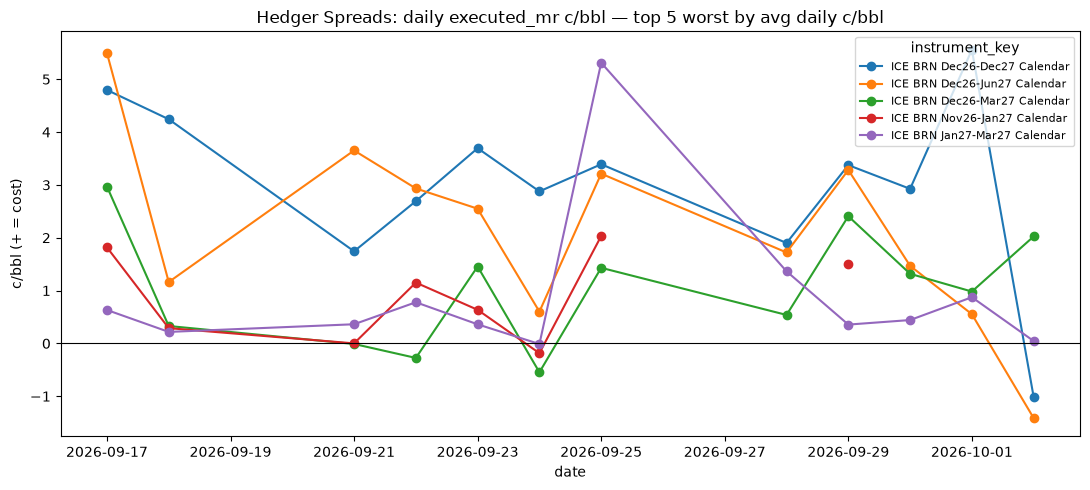

instrument_key,ICE BRN Dec26-Dec27 Calendar,ICE BRN Dec26-Jun27 Calendar,ICE BRN Dec26-Mar27 Calendar,ICE BRN Nov26-Jan27 Calendar,ICE BRN Jan27-Mar27 Calendar
date,,,,,
2026-09-17,4.797,5.496,2.969,1.818,0.632
2026-09-18,4.243,1.162,0.330,0.289,0.218
2026-09-21,1.743,3.652,-0.011,0.000,0.362
2026-09-22,2.692,2.933,-0.275,1.151,0.779
2026-09-23,3.695,2.550,1.455,0.636,0.361
2026-09-24,2.877,0.602,-0.547,-0.185,-0.012
2026-09-25,3.391,3.213,1.431,2.033,5.312
2026-09-28,1.900,1.721,0.539,NaN,1.365
2026-09-29,3.375,3.283,2.407,1.500,0.356


In [6]:
import matplotlib.pyplot as plt

BOOK = 'Hedger Spreads'
START = date(2026, 9, 17)
END = date.today()
TOP_N = 5

dates = [d.date() for d in pd.date_range(START, END, freq='D') if d.weekday() < 5]
rows = []
for d in dates:
    print(f'=== {d} {BOOK} exec mr by contract ===')
    one = executed_mr_by_instrument_book_day(client, d, BOOK)
    if one.empty:
        print('  (no fills)')
        continue
    tmp = one.reset_index()
    tmp.insert(0, 'date', d)
    rows.append(tmp)

if not rows:
    exec_mr_daily = pd.DataFrame()
    worst = []
    print('no data')
else:
    exec_mr_daily = pd.concat(rows, ignore_index=True)
    # contracts only — never treat a summary row as an instrument
    exec_mr_daily = exec_mr_daily[
        exec_mr_daily['instrument_key'].astype(str).str.upper() != 'TOTAL'
    ]

    ranking = (
        exec_mr_daily.groupby('instrument_key', as_index=False)
        .agg(
            executed_mr=('executed_mr', 'sum'),
            abs_lots=('abs_lots', 'sum'),
            n_fills=('n_fills', 'sum'),
            n_days=('date', 'nunique'),
            avg_c_bbl=('c/bbl', 'mean'),  # equal-weight mean of daily slips
        )
    )
    bbls = ranking['abs_lots'] * CONFIG.contract.size
    ranking['range_c/bbl'] = (-ranking['executed_mr'] / bbls.where(bbls > 0) * 100).round(4)
    ranking['avg_c/bbl'] = ranking['avg_c_bbl'].round(4)
    ranking = ranking.drop(columns=['avg_c_bbl'])
    ranking = ranking.sort_values('avg_c/bbl', ascending=False)  # worst avg slip first
    worst = ranking.head(TOP_N)['instrument_key'].tolist()

    print(f'\nTop {TOP_N} worst by average daily c/bbl (+ = cost):')
    display(ranking.head(TOP_N).round(2))

    # daily c/bbl panel for those contracts
    pivot = (
        exec_mr_daily[exec_mr_daily['instrument_key'].isin(worst)]
        .pivot_table(index='date', columns='instrument_key', values='c/bbl', aggfunc='sum')
        .reindex(columns=worst)
        .sort_index()
    )

    ax = pivot.plot(marker='o', figsize=(11, 5))
    ax.set_title(f'{BOOK}: daily executed_mr c/bbl — top {TOP_N} worst by avg daily c/bbl')
    ax.set_ylabel('c/bbl (+ = cost)')
    ax.set_xlabel('date')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.legend(title='instrument_key', loc='best', fontsize=8)
    plt.tight_layout()
    plt.show()

    display(pivot.round(3))

In [8]:
pivot.mean()

instrument_key
ICE BRN Dec26-Dec27 Calendar    3.015250
ICE BRN Dec26-Jun27 Calendar    2.101592
ICE BRN Dec26-Mar27 Calendar    1.051842
ICE BRN Nov26-Jan27 Calendar    0.905275
ICE BRN Jan27-Mar27 Calendar    0.894567
dtype: float64